# Benchmarking OSM tools: pyrosm vs. osmnx, QuackOSM, pyosmium, Osmosis and osmextract

`Pyrosm` aims to be an easy-to-use and fast Python tool for parsing OpenStreetMap data from Protocolbuffer Binary Format (PBF) files into [geopandas](http://geopandas.org/) which is the Python's go-to library for working with spatial data. Pyrosm has been written mainly in Cython (Python with C-like performance) using vectorized operations whenever possible which makes it very efficient for parsing OpenStreetMap data. Pyrosm deserializes the protocol buffer messages using Google’s Protobuf library with its fast C `upb` backend. Google’s Protocol Buffers is a commonly used and efficient method to serialize and compress structured data which is also used by OpenStreetMap contributors to distribute the OSM data in PBF format (Protocolbuffer Binary Format). In addition, Pyrosm uses extensively Numpy array operations and parses geometries using Pygeos which are both excellent choises for fast and memory efficient data manipulation in Python.

To better understand the performance of Pyrosm, here it is compared against other similar tools. There are various tools available for parsing OSM data, such as [OSMnx](https://github.com/gboeing/osmnx), [Osmosis](https://github.com/openstreetmap/osmosis/), [pyosmium/libosmium](https://github.com/osmcode/pyosmium), and [QuackOSM](https://github.com/kraina-ai/quackosm). The most similar tools to Pyrosm (in terms of functionality) is OSMnx which makes it possible to retrieve OpenStreetMap data easily into GeoDataFrames utilizing OverPass API. 

Here, we compare [**pyrosm**](https://pyrosm.readthedocs.io/) against five other
widely used OpenStreetMap tools on a set of **identical, verifiable tasks**:

| Tool | What it is | Reads a local `.osm.pbf`? |
| --- | --- | --- |
| [**pyrosm**](https://pyrosm.readthedocs.io/) | Cython OSM→GeoPandas reader | yes |
| [**osmnx**](https://osmnx.readthedocs.io/) | OSM→GeoPandas/NetworkX via the Overpass API | no (downloads from Overpass) |
| [**QuackOSM**](https://github.com/kraina-ai/quackosm) | DuckDB-based OSM→GeoParquet/GeoPandas reader | yes |
| [**pyosmium**](https://osmcode.org/pyosmium/) | Python bindings to libosmium (streaming C++ reader/writer) | yes |
| [**Osmosis**](https://wiki.openstreetmap.org/wiki/Osmosis) | Java command-line tool for manipulating PBF data | yes |
| [**osmextract**](https://github.com/ropensci/osmextract) | R package: downloads and reads OSM via GDAL into `sf` | yes |

We benchmark three tasks:

1. **Parse buildings** from a region into a GeoDataFrame.
2. **Parse the road network** (`highway=*` ways) from the same region into a GeoDataFrame.
3. **Crop a large PBF** (all of Finland) down to the Helsinki region and **write the result back to disk** as a new `.osm.pbf`.

### How the comparison is kept fair

- **Same input.** For the parsing tasks every local-file tool reads the *same* PBF; OSMnx
  queries the Overpass API for the *same* geographic extent (the bounding box of that PBF).
- **Same selection.** Each tool is given the same OSM tag filter (`building` / `highway`).
- **Same output, compared by geometry type.** OSM tools disagree on whether a tag filter
  should also return tagged *nodes* (e.g. `highway=bus_stop`) or *areas*. To compare "apples with
  apples", we normalise every result to the geometry that defines the task — **polygons** for
  buildings, **lines** for roads — and report those counts side by side so you can confirm the
  tools really did the same work.
- **Timing based on multiple runs.** Each task is timed with a wall-clock median over `REPEATS` runs. QuackOSM
  is called with `ignore_cache=True` so we measure parsing, not a cache hit.
- **Verified cropping.** Each cropped PBF is read back and its building count compared, so a
  "fast" crop that dropped data is caught.

> **Not every tool can do every task.** OSMnx works from the Overpass API and does not read or
> crop local PBF files, so it does not take part in the cropping task. Osmosis manipulates PBF
> data and does not build GeoDataFrames, so it does not take part in the parsing tasks. osmextract
> (an R package) reads OSM layers through GDAL into `sf`/GeoPackage rather than writing a cropped
> `.osm.pbf`, so it joins the parsing tasks but not the cropping task. Being an R tool, its parsing results
> are produced by the companion **`osmextract_benchmark.ipynb`** (run with an R kernel), which
> writes `osmextract_results.csv`; the cell below loads it. The code
> below simply skips any tool that is not installed or not applicable.

**Hardware:** The benchmarks are conducted with MacBook Air M5 laptop with 24GB of RAM and SSD-disk running on MacOS Tahoe 26.5.  

## Installation

All six tools (plus the notebook's plotting/dataframe deps) can be installed into one
environment. pyrosm, osmnx, QuackOSM and pyosmium are Python packages; Osmosis is a Java tool;
osmextract is an R package.

```bash
# Python tools (conda-forge recommended for the geo-stack)
# ipywidgets is needed so QuackOSM/DuckDB can manage their progress bar inside Jupyter.
mamba install -c conda-forge pyrosm osmnx quackosm pyosmium geopandas matplotlib pandas ipywidgets

# Osmosis (Java command-line tool) + a Java runtime
mamba install -c conda-forge openjdk
# then download Osmosis from https://github.com/openstreetmap/osmosis/releases
# and make sure the `osmosis` launcher is on your PATH.

# osmextract is an R package (run via the companion osmextract_benchmark.ipynb).
# Install R + sf (GDAL) + the Jupyter R kernel from conda-forge, then osmextract from CRAN:
mamba install -c conda-forge r-base r-sf r-irkernel
R -e 'install.packages("osmextract", repos="https://cloud.r-project.org")'
R -e 'IRkernel::installspec()'   # registers the "R" Jupyter kernel
```

If a tool is missing, its cells below are skipped automatically (they are guarded by an
availability check), so the rest of the notebook still runs end to end.


## Setup: imports, tool detection and helpers

In [1]:
import os
import time
import shutil
import statistics
import subprocess
import tempfile
import warnings
from pathlib import Path

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")  # keep the benchmark output readable

# How many times each parsing task is repeated (median is reported).
REPEATS = 3
# Cropping reads/writes a multi-hundred-MB file; once is enough.
CROP_REPEATS = 1

In [2]:
# Detect which tools are available
HAVE = {}

import pyrosm
from pyrosm import OSM, get_data
import osmnx as ox
import quackosm as qosm
import osmium
from importlib.metadata import version

# Osmosis is a command-line tool; detect it on PATH.
OSMOSIS_BIN = shutil.which("osmosis")

HAVE["pyrosm"] = pyrosm.__version__
HAVE["osmnx"] = ox.__version__
HAVE["quackosm"] = qosm.__version__
HAVE["pyosmium"] = version("osmium")
HAVE["osmosis"] = OSMOSIS_BIN

print("Detected tools:")
for k, v in HAVE.items():
    print(f"  {k:9s}: {v if v else 'NOT available'}")

Detected tools:
  pyrosm   : 0.8.0
  osmnx    : 2.1.0
  quackosm : 0.17.1
  pyosmium : 4.3.1
  osmosis  : /opt/homebrew/bin/osmosis


In [3]:
# ---- timing + result collection -------------------------------------------
# One row per (task, tool)
RESULTS = []  

# Geometry types
POLY = {"Polygon", "MultiPolygon"}
LINE = {"LineString", "MultiLineString"}

def bench(fn, repeats=1):
    """Run fn `repeats` times; return (median_seconds, last_result)."""
    times, result = [], None
    for _ in range(repeats):
        t0 = time.perf_counter()
        result = fn()
        times.append(time.perf_counter() - t0)
    return statistics.median(times), result

def count_poly(gdf):
    return int(gdf.geometry.geom_type.isin(POLY).sum())

def count_line(gdf):
    return int(gdf.geometry.geom_type.isin(LINE).sum())

def run_parse(task, tool, fn, counter, repeats=REPEATS):
    """Time a parsing task for one tool, record the normalised feature count."""
    if not HAVE.get(tool):
        print(f"  {tool:9s} skipped (not available)")
        return None
    try:
        sec, gdf = bench(fn, repeats)
        n = counter(gdf)
        RESULTS.append(dict(task=task, tool=tool, seconds=round(sec, 2),
                            features=n, status="ok"))
        print(f"  {tool:9s} {sec:7.2f} s   features={n}")
        return gdf
    except Exception as e:
        RESULTS.append(dict(task=task, tool=tool, seconds=None,
                            features=None, status=f"{type(e).__name__}: {e}"))
        print(f"  {tool:9s} ERROR: {type(e).__name__}: {e}")
        return None

In [4]:
# ---- pyosmium helpers (streaming reader + writer) -------------------------
# pyosmium has no GeoDataFrame API, so we assemble geometries (WKB factory) and read
# each element's tags ourselves, so the result is a full attribute table like the others.

def pyosmium_polygons(pbf_path, key):
    """All areas (closed ways + multipolygon relations) carrying `key` -> polygons + tags."""
    from shapely import from_wkb
    fab = osmium.geom.WKBFactory()
    records = []
    for o in (osmium.FileProcessor(pbf_path)
              .with_areas()
              .with_filter(osmium.filter.KeyFilter(key))):
        if o.is_area():
            try:
                wkb = fab.create_multipolygon(o)
                if wkb:
                    rec = {t.k: t.v for t in o.tags}
                    rec["geometry"] = from_wkb(bytes.fromhex(wkb))
                    records.append(rec)
            except Exception:
                pass
    return gpd.GeoDataFrame(records, crs="EPSG:4326")

def pyosmium_lines(pbf_path, key):
    """All ways carrying `key` -> linestrings + tags."""
    from shapely import from_wkb
    fab = osmium.geom.WKBFactory()
    records = []
    for o in (osmium.FileProcessor(pbf_path)
              .with_locations()
              .with_filter(osmium.filter.KeyFilter(key))):
        if o.is_way() and len(o.nodes) >= 2:
            try:
                wkb = fab.create_linestring(o)
                if wkb:
                    rec = {t.k: t.v for t in o.tags}
                    rec["geometry"] = from_wkb(bytes.fromhex(wkb))
                    records.append(rec)
            except Exception:
                pass
    return gpd.GeoDataFrame(records, crs="EPSG:4326")

def pyosmium_crop(in_pbf, out_pbf, bbox):
    """Complete-ways bounding-box extract, mirroring `osmium extract` / Osmosis.

    Pass 1: node ids inside the box. Pass 2: ways touching the box, keeping ALL of
    their nodes (so boundary-crossing ways stay whole). Pass 3: write kept
    nodes/ways/relations in file order.
    """
    if os.path.exists(out_pbf):
        os.remove(out_pbf)
    west, south, east, north = bbox
    in_box = set()
    for n in (osmium.FileProcessor(in_pbf)
              .with_filter(osmium.filter.EntityFilter(osmium.osm.NODE))):
        loc = n.location
        if west <= loc.lon <= east and south <= loc.lat <= north:
            in_box.add(n.id)
    keep_ways, keep_nodes = set(), set(in_box)
    for w in (osmium.FileProcessor(in_pbf)
              .with_filter(osmium.filter.EntityFilter(osmium.osm.WAY))):
        refs = [nd.ref for nd in w.nodes]
        if any(r in in_box for r in refs):
            keep_ways.add(w.id)
            keep_nodes.update(refs)
    writer = osmium.SimpleWriter(out_pbf)
    try:
        for o in osmium.FileProcessor(in_pbf):
            if o.is_node():
                if o.id in keep_nodes:
                    writer.add_node(o)
            elif o.is_way():
                if o.id in keep_ways:
                    writer.add_way(o)
            elif o.is_relation():
                if any((m.type == "w" and m.ref in keep_ways) or
                       (m.type == "n" and m.ref in keep_nodes) for m in o.members):
                    writer.add_relation(o)
    finally:
        writer.close()
    return out_pbf

def osmosis_crop(in_pbf, out_pbf, bbox, osmosis_bin):
    """Bounding-box extract with Osmosis (complete ways), via its command line."""
    if os.path.exists(out_pbf):
        os.remove(out_pbf)
    west, south, east, north = bbox
    subprocess.run(
        [osmosis_bin, "--read-pbf", str(in_pbf),
         "--bounding-box", f"left={west}", f"bottom={south}",
         f"right={east}", f"top={north}", "completeWays=yes",
         "--write-pbf", str(out_pbf)],
        check=True,
    )
    return out_pbf

## Data 

- **Parsing tasks** use the **Helsinki Region** extract (~35 MB) — small enough that the
  Overpass API (and therefore OSMnx) can serve the same area for a fair comparison.
- **Cropping task** uses **all of Finland** (a few hundred MB from Geofabrik) as the large
  input that gets cropped down to the Helsinki region.

Both are downloaded automatically by `pyrosm.get_data(...)`. The Finland download is large and
may take a while the first time.

In [5]:
REGION_PBF = get_data("helsinki_region_pbf")   # ~35 MB, used for parsing tasks
FINLAND_PBF = get_data("finland")               # large, used as the crop input

# Helsinki region bounding box (west, south, east, north) for the cropping task.
HELSINKI_BBOX = [24.50, 60.10, 25.25, 60.40]

# QuackOSM writes intermediate GeoParquet to a working directory; keep it out of the repo.
QUACKOSM_WORKDIR = os.path.join(tempfile.gettempdir(), "quackosm_cache")

print("Region PBF :", REGION_PBF, f"({os.path.getsize(REGION_PBF)/1e6:.1f} MB)")
print("Finland PBF:", FINLAND_PBF, f"({os.path.getsize(FINLAND_PBF)/1e6:.1f} MB)")

Region PBF : /var/folders/f2/pgp09jl542zffhtrt2hx8zhh0000gp/T/pyrosm/Helsinki_region.osm.pbf (36.7 MB)
Finland PBF: /var/folders/f2/pgp09jl542zffhtrt2hx8zhh0000gp/T/pyrosm/finland-latest.osm.pbf (724.7 MB)


## Task 1 — Parse buildings into a GeoDataFrame

Every tool selects features tagged `building` and we compare the number of **building
polygons** produced. pyrosm runs first; its data extent defines the area of interest (`AOI`)
that OSMnx then requests from Overpass, so both look at the same region.

In [6]:
AOI = None  # set from pyrosm's result, reused for the OSMnx (Overpass) query

print("Task 1 — buildings (counts are building polygons):")

# pyrosm — reads the local PBF
def _pyrosm_buildings():
    return OSM(REGION_PBF).get_buildings()
_g = run_parse("buildings", "pyrosm", _pyrosm_buildings, count_poly)
if _g is not None:
    from shapely.geometry import box
    AOI = box(*_g.total_bounds)

# QuackOSM — reads the local PBF (ignore_cache so we time parsing, not a cache hit)
def _quackosm_buildings():
    return qosm.convert_pbf_to_geodataframe(
        REGION_PBF, tags_filter={"building": True},
        explode_tags=True, keep_all_tags=True, ignore_cache=True,
        verbosity_mode="silent", working_directory=QUACKOSM_WORKDIR)
run_parse("buildings", "quackosm", _quackosm_buildings, count_poly)

# pyosmium — streams the local PBF
def _pyosmium_buildings():
    return pyosmium_polygons(REGION_PBF, "building")
run_parse("buildings", "pyosmium", _pyosmium_buildings, count_poly)

# OSMnx — downloads the same area from the Overpass API
def _osmnx_buildings():
    return ox.features_from_polygon(AOI, tags={"building": True})
if AOI is not None:
    run_parse("buildings", "osmnx", _osmnx_buildings, count_poly, repeats=1)

Task 1 — buildings (counts are building polygons):
  pyrosm       6.13 s   features=175972
  quackosm    15.26 s   features=175971
  pyosmium    14.73 s   features=175970
  osmnx       33.49 s   features=223263


## Task 2 — Parse the road network into a GeoDataFrame

Every tool selects features tagged `highway` and we compare the number of **road lines**.
Tagged nodes (bus stops, crossings) and pedestrian *areas* are normalised away by counting
only `LineString`/`MultiLineString` geometries, so each tool reports the same kind of object.

In [7]:
print("Task 2 — roads (counts are highway lines):")

# pyrosm — generic highway filter as lines (keep_nodes=False to match the other tools)
def _pyrosm_roads():
    return OSM(REGION_PBF).get_data_by_custom_criteria(
        {"highway": True}, filter_type="keep", keep_nodes=False, keep_relations=False)
run_parse("roads", "pyrosm", _pyrosm_roads, count_line)

# QuackOSM
def _quackosm_roads():
    return qosm.convert_pbf_to_geodataframe(
        REGION_PBF, tags_filter={"highway": True},
        explode_tags=True, keep_all_tags=True, ignore_cache=True,
        verbosity_mode="silent", working_directory=QUACKOSM_WORKDIR)
run_parse("roads", "quackosm", _quackosm_roads, count_line)

# pyosmium
def _pyosmium_roads():
    return pyosmium_lines(REGION_PBF, "highway")
run_parse("roads", "pyosmium", _pyosmium_roads, count_line)

# OSMnx — Overpass, same area. graph_from_polygon(network_type="all") fetches only the
# highway *ways*. The result is OSMnx's
# routing graph (intersection-to-intersection edges), so the line count differs from the
# raw-way tools. use_cache is off so each of the runs really hits Overpass (like
# QuackOSM's ignore_cache), not a cached response.
def _osmnx_roads():
    G = ox.graph_from_polygon(AOI, network_type="all", retain_all=True)
    return ox.graph_to_gdfs(G, nodes=False)
if AOI is not None:
    ox.settings.use_cache = False
    run_parse("roads", "osmnx", _osmnx_roads, count_line, repeats=1)
    

Task 2 — roads (counts are highway lines):
  pyrosm       8.80 s   features=192587
  quackosm    41.31 s   features=192084
  pyosmium    45.23 s   features=194353
  osmnx       99.02 s   features=1178911


OSMnx's road task originally used `features_from_polygon(AOI, tags={"highway": True})`, which also requests every highway-tagged *node* (bus stops, crossings, street lamps, …) and did not complete in over an hour on the public Overpass API. The cell above instead uses `graph_from_polygon(AOI, network_type="all")`, which fetches only the highway **ways** and completes. The result is OSMnx's routing graph, so its edges are intersection-to-intersection segments rather than raw OSM ways, and the road-line count differs from the local-file tools accordingly.

## Task 3 — Crop a large PBF to a region and save to disk

Crop the **Finland** PBF down to the **Helsinki region** bounding box and write a new
`.osm.pbf`. All three croppers keep **complete ways** (ways crossing the box keep all their
nodes), so the outputs are directly comparable. Each result is read back and its building
count reported to confirm the crop is a valid subset (the full Finland file has far more).

OSMnx and QuackOSM are not part of this task: OSMnx does not handle local PBF files, and
QuackOSM converts PBF to GeoParquet rather than writing a cropped `.osm.pbf`.

In [8]:
print("Task 3 — crop Finland -> Helsinki region (buildings = count read back from the crop):")

CROP_RESULTS = []
_crop_dir = tempfile.gettempdir()

def run_crop(tool, fn):
    if not HAVE.get(tool):
        print(f"  {tool:9s} skipped (not available)")
        return
    try:
        sec, out = bench(fn, CROP_REPEATS)
        size_mb = os.path.getsize(out) / 1e6
        n_buildings = len(OSM(out).get_buildings())   # read back to verify the subset
        CROP_RESULTS.append(dict(tool=tool, seconds=round(sec, 1),
                                 out_mb=round(size_mb, 1), buildings=n_buildings,
                                 status="ok"))
        print(f"  {tool:9s} {sec:7.1f} s   out={size_mb:6.1f} MB   buildings={n_buildings}")
    except Exception as e:
        CROP_RESULTS.append(dict(tool=tool, seconds=None, out_mb=None,
                                 buildings=None, status=f"{type(e).__name__}: {e}"))
        print(f"  {tool:9s} ERROR: {type(e).__name__}: {e}")

# pyrosm — OSM(..., bounding_box=...).to_pbf(...)
def _pyrosm_crop():
    out = os.path.join(_crop_dir, "crop_pyrosm_repack.osm.pbf")
    if os.path.exists(out):
        os.remove(out)
    OSM(FINLAND_PBF, bounding_box=HELSINKI_BBOX).to_pbf(out, repack=True)
    return out
run_crop("pyrosm", _pyrosm_crop)

# pyosmium — complete-ways extract written with SimpleWriter
def _pyosmium_crop():
    out = os.path.join(_crop_dir, "crop_pyosmium.osm.pbf")
    return pyosmium_crop(FINLAND_PBF, out, HELSINKI_BBOX)
run_crop("pyosmium", _pyosmium_crop)

# Osmosis — the classic --bounding-box --write-pbf pipeline
def _osmosis_crop():
    out = os.path.join(_crop_dir, "crop_osmosis.osm.pbf")
    return osmosis_crop(FINLAND_PBF, out, HELSINKI_BBOX, OSMOSIS_BIN)
run_crop("osmosis", _osmosis_crop)



Task 3 — crop Finland -> Helsinki region (buildings = count read back from the crop):
  pyrosm      112.5 s   out=  59.5 MB   buildings=208586
  pyosmium    272.8 s   out=  59.5 MB   buildings=208586


Jun 14, 2026 11:38:56 PM org.openstreetmap.osmosis.core.Osmosis run
INFO: Osmosis Version 0.49.2
SLF4J: Failed to load class "org.slf4j.impl.StaticLoggerBinder".
SLF4J: Defaulting to no-operation (NOP) logger implementation
SLF4J: See http://www.slf4j.org/codes.html#StaticLoggerBinder for further details.
Jun 14, 2026 11:38:56 PM org.openstreetmap.osmosis.core.Osmosis run
INFO: Preparing pipeline.
Jun 14, 2026 11:38:56 PM org.openstreetmap.osmosis.core.Osmosis run
INFO: Launching pipeline execution.
Jun 14, 2026 11:38:56 PM org.openstreetmap.osmosis.core.Osmosis run
INFO: Pipeline executing, waiting for completion.
Jun 14, 2026 11:41:33 PM org.openstreetmap.osmosis.core.Osmosis run
INFO: Pipeline complete.
Jun 14, 2026 11:41:33 PM org.openstreetmap.osmosis.core.Osmosis run
INFO: Total execution time: 156443 milliseconds.


  osmosis     156.6 s   out=  59.1 MB   buildings=208586


## Task 3 with multiprocessing / multithreading — does parallelism speed up the crop?

Re-run the Finland → Helsinki crop in parallel, using each tool's own mechanism:

- **pyrosm** parallelises the extract across **processes** — `to_pbf(..., workers=N)`; compared here at `workers=1` vs `workers=8`.
- **pyosmium / libosmium** threads the PBF block **(de)compression** via the `OSMIUM_POOL_THREADS` pool, which is **on by default** (pool ≈ CPU count). It is compared at 1 vs 8 threads; because the kernel's osmium pool is already initialised by the parsing tasks, the thread count is set in a fresh **subprocess** (this adds a small fixed start-up). libosmium threads only the (de)compression — the per-element extract loop is single-threaded Python — so the benefits of multithreading in Python is limited via pyosmium (considering slow Python loops).
- **Osmosis**'s `--bounding-box` pipeline has no worker/thread count, so it is left out from this comparison.

Each output is read back and its building count reported, exactly like Task 3, so every parallel crop is verified to keep the same data.

In [ ]:
print("Task 3 in parallel — each cropper's own multiprocessing / multithreading:")

N_WORKERS = 8
CROP_MP_RESULTS = []

def run_crop_workers(label, tool, fn):
    """Like run_crop, but records the parallelism setting used in each row."""
    if not HAVE.get(tool):
        print(f"  {label:28s} skipped (not available)")
        return
    try:
        sec, out = bench(fn, CROP_REPEATS)
        size_mb = os.path.getsize(out) / 1e6
        n_buildings = len(OSM(out).get_buildings())   # read back to verify the subset
        CROP_MP_RESULTS.append(dict(run=label, tool=tool, seconds=round(sec, 1),
                                    out_mb=round(size_mb, 1), buildings=n_buildings,
                                    status="ok"))
        print(f"  {label:28s} {sec:7.1f} s   out={size_mb:6.1f} MB   buildings={n_buildings}")
    except Exception as e:
        CROP_MP_RESULTS.append(dict(run=label, tool=tool, seconds=None, out_mb=None,
                                    buildings=None, status=f"{type(e).__name__}: {e}"))
        print(f"  {label:28s} ERROR: {type(e).__name__}: {e}")

# --- pyrosm: real multi-PROCESS workers (parallelises the extract itself) ---
def _pyrosm_crop_n(n):
    def _fn():
        out = os.path.join(_crop_dir, f"crop_pyrosm_w{n}.osm.pbf")
        if os.path.exists(out):
            os.remove(out)
        OSM(FINLAND_PBF, bounding_box=HELSINKI_BBOX).to_pbf(out, workers=n, repack=True)
        return out
    return _fn
run_crop_workers("pyrosm workers=1", "pyrosm", _pyrosm_crop_n(1))
run_crop_workers(f"pyrosm workers={N_WORKERS}", "pyrosm", _pyrosm_crop_n(N_WORKERS))

# --- pyosmium: libosmium multi-THREADED PBF (de)compression via OSMIUM_POOL_THREADS
#     (on by default, pool ~ CPU count). The kernel already initialised osmium's pool in
#     the parsing tasks, so to *control* the thread count we crop in a fresh subprocess
#     with the env var set. libosmium threads only the (de)compression; the per-element
#     extract loop is single-threaded Python, so this saturates after ~2 threads.
import sys
import inspect
_OE_POOL_SCRIPT = os.path.join(_crop_dir, "_pyosmium_crop_pooled.py")
with open(_OE_POOL_SCRIPT, "w") as _f:
    _f.write("import os, sys, osmium\n\n")
    _f.write(inspect.getsource(pyosmium_crop))   # reuse the exact Task 3 crop logic
    _f.write("\n\nif __name__ == '__main__':\n"
             "    pyosmium_crop(sys.argv[1], sys.argv[2], [float(x) for x in sys.argv[3:7]])\n")

def _pyosmium_crop_pool(threads):
    def _fn():
        out = os.path.join(_crop_dir, f"crop_pyosmium_pool{threads}.osm.pbf")
        env = dict(os.environ, OSMIUM_POOL_THREADS=str(threads))
        subprocess.run([sys.executable, _OE_POOL_SCRIPT, FINLAND_PBF, out,
                        *(str(v) for v in HELSINKI_BBOX)], env=env, check=True)
        return out
    return _fn
run_crop_workers("pyosmium pool_threads=1", "pyosmium", _pyosmium_crop_pool(1))
run_crop_workers("pyosmium pool_threads=8", "pyosmium", _pyosmium_crop_pool(8))


if CROP_MP_RESULTS:
    display(pd.DataFrame(CROP_MP_RESULTS))

## Results

In [9]:
# osmextract results come from the companion osmextract_benchmark.ipynb (R kernel),
# which writes osmextract_results.csv next to this notebook. Load and merge them here.
_oe_csv = Path("osmextract_results.csv")
if _oe_csv.exists():
    _oe = pd.read_csv(_oe_csv).to_dict("records")
    _seen = {(r["task"], r["tool"]) for r in RESULTS}
    _new = [r for r in _oe if (r["task"], r["tool"]) not in _seen]
    RESULTS.extend(_new)
    print(f"Loaded {len(_new)} osmextract row(s) from {_oe_csv}")
else:
    print("osmextract_results.csv not found -- run osmextract_benchmark.ipynb (R) to add osmextract.")

osmextract_results.csv not found -- run osmextract_benchmark.ipynb (R) to add osmextract.


In [10]:
parse_df = pd.DataFrame(RESULTS)
print("Parsing tasks (seconds = median wall-clock; features = normalised count):")
display(parse_df)

if CROP_RESULTS:
    crop_df = pd.DataFrame(CROP_RESULTS)
    print("\nCropping task:")
    display(crop_df)

Parsing tasks (seconds = median wall-clock; features = normalised count):


,task,tool,seconds,features,status
0,buildings,pyrosm,6.13,175972,ok
1,buildings,quackosm,15.26,175971,ok
2,buildings,pyosmium,14.73,175970,ok
3,buildings,osmnx,33.49,223263,ok
4,roads,pyrosm,8.80,192587,ok
5,roads,quackosm,41.31,192084,ok
6,roads,pyosmium,45.23,194353,ok
7,roads,osmnx,99.02,1178911,ok



Cropping task:


,tool,seconds,out_mb,buildings,status
0,pyrosm,112.5,59.5,208586,ok
1,pyosmium,272.8,59.5,208586,ok
2,osmosis,156.6,59.1,208586,ok


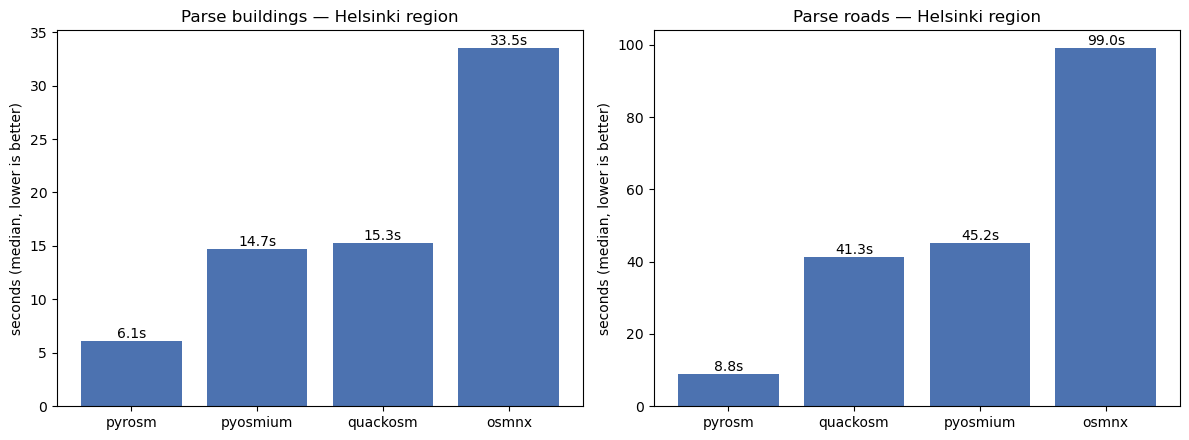

In [11]:
# Bar charts of the parsing timings (only the rows that succeeded).
ok = parse_df[parse_df["status"] == "ok"]
if not ok.empty:
    tasks = ["buildings", "roads"]
    fig, axes = plt.subplots(1, len(tasks), figsize=(12, 4.5), sharey=False)
    for ax, task in zip(axes, tasks):
        sub = ok[ok["task"] == task].sort_values("seconds")
        ax.bar(sub["tool"], sub["seconds"], color="#4C72B0")
        ax.set_title(f"Parse {task} — Helsinki region")
        ax.set_ylabel("seconds (median, lower is better)")
        for x, y in zip(sub["tool"], sub["seconds"]):
            ax.text(x, y, f"{y:.1f}s", ha="center", va="bottom")
    plt.tight_layout()
    plt.show()

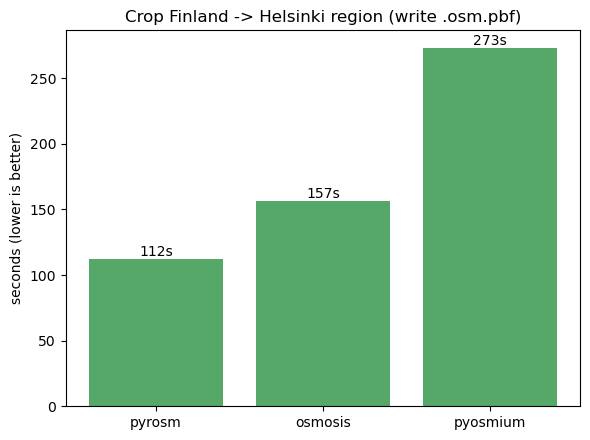

In [12]:
# Bar chart of the cropping timings.
if CROP_RESULTS:
    okc = crop_df[crop_df["status"] == "ok"].sort_values("seconds")
    if not okc.empty:
        fig, ax = plt.subplots(figsize=(6, 4.5))
        ax.bar(okc["tool"], okc["seconds"], color="#55A868")
        ax.set_title("Crop Finland -> Helsinki region (write .osm.pbf)")
        ax.set_ylabel("seconds (lower is better)")
        for x, y in zip(okc["tool"], okc["seconds"]):
            ax.text(x, y, f"{y:.0f}s", ha="center", va="bottom")
        plt.tight_layout()
        plt.show()

## 7. Interpreting the results

A few things to keep in mind so the numbers are read fairly:

- **Counts confirm the tasks match.** The building-polygon and road-line counts line up
  across the local-file tools (typically within a fraction of a percent), which is the evidence
  that each tool really parsed the same features. OSMnx counts can differ a little more because
  it fetches **live** data from Overpass, which is a newer snapshot than the downloaded PBF.

- **Different tools are built for different jobs:**
  - **pyosmium** streams in C++ and builds the geometry you ask for and nothing else, so it is
    typically the fastest at extracting a *single* feature type from a file.
  - **pyrosm** parses the whole PBF into rich GeoDataFrames (all tag columns) and is designed so
    that once an `OSM` object is initialised, *every* further layer (buildings, roads, POIs, …)
    is served from memory — its advantage grows when you need several datasets from one area.
  - **QuackOSM** runs a DuckDB pipeline: it has more fixed start-up cost on a small file but is
    very memory-efficient and scales well to country/continent-sized inputs.
  - **OSMnx** trades speed for convenience and global coverage — no local file needed, but every
    query is an Overpass API round-trip.
  - **Osmosis / pyosmium** are the PBF-manipulation tools for the cropping job; pyrosm's
    `to_pbf` brings the same capability into the GeoPandas workflow.

- **One area vs. many layers.** The single-layer parsing tasks above favour streaming tools. To
  see pyrosm's parse-once design, time `get_buildings()`, `get_network()` and
  `get_pois()` from one `OSM(REGION_PBF)` instance versus reading the file three times with the
  others — the cell below sketches that comparison.

In [13]:
# Optional: pyrosm parse-once vs. reading the file once per layer with pyosmium.
if HAVE.get("pyrosm") and HAVE.get("pyosmium"):
    # pyrosm: read once, then three layers from memory
    t0 = time.perf_counter()
    _osm = OSM(REGION_PBF)
    _ = _osm.get_buildings()
    _ = _osm.get_data_by_custom_criteria({"highway": True}, filter_type="keep",
                                         keep_nodes=False, keep_relations=False)
    _ = _osm.get_pois({"amenity": True})
    pyrosm_multi = time.perf_counter() - t0

    # pyosmium: a separate streaming pass per layer
    t0 = time.perf_counter()
    _ = pyosmium_polygons(REGION_PBF, "building")
    _ = pyosmium_lines(REGION_PBF, "highway")
    _ = pyosmium_polygons(REGION_PBF, "amenity")  # rough POI proxy
    pyosmium_multi = time.perf_counter() - t0

    print(f"buildings + roads + POIs from the same area:")
    print(f"  pyrosm   (parse once, 3 layers from memory): {pyrosm_multi:6.2f} s")
    print(f"  pyosmium (3 separate streaming passes):       {pyosmium_multi:6.2f} s")

buildings + roads + POIs from the same area:
  pyrosm   (parse once, 3 layers from memory):  12.20 s
  pyosmium (3 separate streaming passes):        54.70 s
